In [21]:
import os
import xarray as xr
import glob
import rioxarray
import rasterio
import geopandas as gpd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from shapely.geometry import box
from dask.diagnostics import ProgressBar


In [ ]:
# setting file paths

data_dir = "/global/scratch/users/yougsanghvi/era5_gdnat_panel_diff/"


# Load US counties shapefile
shp_path = "/global/scratch/users/yougsanghvi/tl_2016_us_county_mortality.shp" 
counties = gpd.read_file(shp_path)
counties = counties.to_crs("EPSG:4326")  # Ensure it matches lat/lon


In [30]:
years = range(2000, 2005)  # inclusive of 2004

# Open all datasets into a list
datasets = []
for year in years:
    file_path = os.path.join(data_dir, f"era5_gdnat_diff_{year}.nc")
    ds = xr.open_dataset(file_path)
    var = list(ds.data_vars)[0]  # get variable name
    datasets.append(ds[var])

# Concatenate along time dimension
merged = xr.concat(datasets, dim="time")

# Take mean across time
mean_diff = merged.mean(dim="time", skipna=True)

# Convert longitudes first (before slicing)
usa_diff = mean_diff.assign_coords(
    longitude=(((mean_diff.longitude + 180) % 360) - 180)
).sortby("longitude")

# Then slice lat and lon in [-180, 180] range
usa_diff = usa_diff.sel(
    latitude=slice(50, 24),    # 50 to 24 descending latitude
    longitude=slice(-130, -65) # typical CONUS longitudes
)



/tmp/ipykernel_117848/2905376573.py:7: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(file_path)
/tmp/ipykernel_117848/2905376573.py:7: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(file_path)
/tmp/ipykernel_117848/2905376573.py:7: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(file_path)
/tmp/ipykernel_117848/2905376573.py:7: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta 

ERROR 1: PROJ: internal_proj_create_from_database: /global/software/rocky-8.x86_64/gcc/linux-rocky8-x86_64/gcc-11.4.0/proj-9.2.1-bbhelefiajxgp4kdvlkru6cicfl3ty5t/share/proj/proj.db contains DATABASE.LAYOUT.VERSION.MINOR = 2 whereas a number >= 3 is expected. It comes from another PROJ installation.
/tmp/ipykernel_117848/2345492299.py:9: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  us_boundary = counties.unary_union


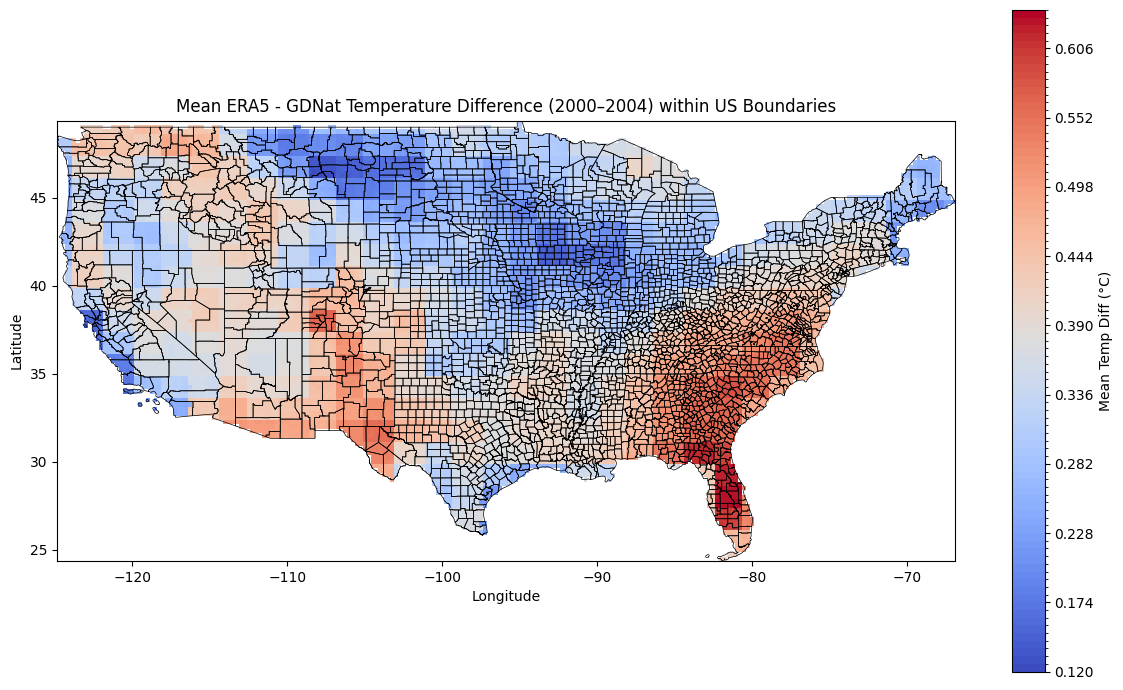

In [ ]:
import geopandas as gpd
import rioxarray

# Step 0: Make sure usa_diff has CRS set (WGS84)
if not usa_diff.rio.crs:
    usa_diff = usa_diff.rio.write_crs("EPSG:4326")

# Step 1: Create a single US boundary polygon from counties
us_boundary = counties.unary_union

# Step 2: Mask raster with US boundary polygon
# Convert the shapely geometry to GeoDataFrame for rioxarray mask
us_gdf = gpd.GeoDataFrame(geometry=[us_boundary], crs="EPSG:4326")

# Mask the raster - crops and masks outside US polygon
masked_usa_diff = usa_diff.rio.clip(us_gdf.geometry, us_gdf.crs, drop=True, invert=False)

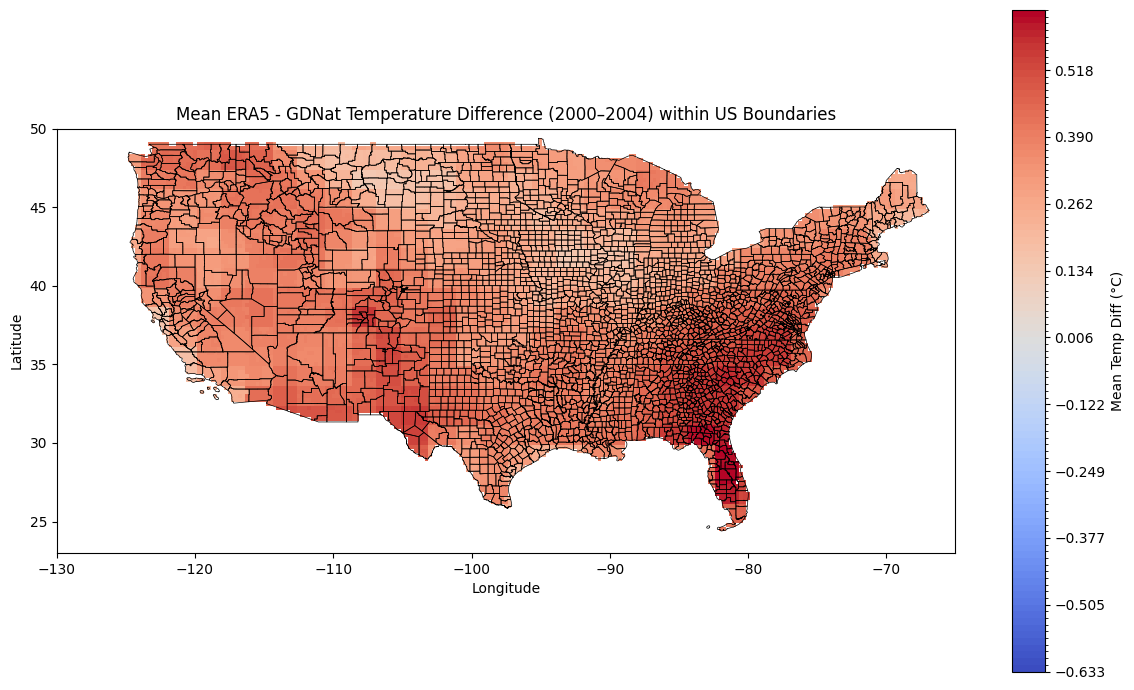

In [46]:
import numpy as np

# Compute max absolute value for symmetric colorbar limits
max_abs = np.abs(masked_usa_diff).max().item()

fig, ax = plt.subplots(figsize=(12, 7))

masked_usa_diff.plot(
    ax=ax,
    cmap="coolwarm",
    vmin=-max_abs,
    vmax= max_abs,
    cbar_kwargs={"label": "Mean Temp Diff (°C)"},
    rasterized=True,
    levels=100,
    add_colorbar=True,
    add_labels=False
)

counties.boundary.plot(ax=ax, linewidth=0.5, edgecolor='black')

ax.set_xlim(-130, -65)
ax.set_ylim(23, 50)

ax.set_title("Mean ERA5 - GDNat Temperature Difference (2000–2004) within US Boundaries")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.tight_layout()
plt.show()
